# Operational Screening of Wine Bottling Lots (Red + White)

*MLN601 Assessment 2 - Decision Tree Classification and CRISP-DM*

Design and Creative Technologies, Torrens University

- **Student:** Luis Guilherme de Barros Andrade Faria - A00187785
- **Subject Name:** Machine Learning
- **Subject Code:** MLN 601
- **Title:** Operational Screening of Wine Bottling Lots (Red + White)
- **Lecturer:** Dr. Kamran Shaukat
- **Assessment No.:** 2
- **Date:** July 2026

| Field | Value |
|---|---|
| Dataset | UCI Wine Quality - red + white combined (Cortez et al., 2009) |
| Target | Low (`quality < 6`) = 1; high (`quality >= 6`) = 0 |
| Required algorithm | Decision Tree - default, AUC-tuned and balanced variants |
| Sensitivity studies | Leakage-safe SMOTE and kernel SVM benchmark |
| Methodology | CRISP-DM |

Each row in the UCI dataset is one laboratory sample. In this project, I treat that single sample as standing in for a whole bottling lot, assuming the lot is homogeneous - I am not classifying individual bottles. The model's job is to flag lots with a higher risk of low sensory quality so the quality-control team can send them for extra tasting or testing. It is a decision-support tool, where a human always makes the final call, and no lot is ever released or rejected automatically.

Quality is a subjective, ordinal score, so every model is framed as an interpretable decision-support tool, not a replacement for expert tasting.

## 1. Business Understanding

A wine producer needs to release bottling lots efficiently,  without letting low-quality lots reach distribution. Each row in the dataset is one laboratory-tested wine sample, which here stands for one bottling lot. The business question is: 

> *Can a model flag the lots at higher risk of low sensory quality, so they are sent for extra tasting or testing before release?*

Following the brief, `quality < 6` is considered low (class 1) and `quality >= 6` is considered high (class 0). The model's output is a binary classification, where the positive class (1) indicates a lot that should be sent for extra tasting or testing.

Operationally, a false negative (a low-quality lot classified as high-quality) is more costly than a false positive (a high-quality lot classified as low-quality). The model is therefore a triage layer between laboratory testing and human tasting, and it is designed to be interpretable so that quality-control staff can understand the reasoning behind its predictions and make the final call - the model never releases or rejects a lot on its own.

Success is defined **before modelling**: in five-fold cross-validation (CV), the training data is divided into 5 parts, the model trains on 4 and validates on the 5th, rotating until every part has been used for validation. A candidate must achieve:
- ROC-AUC >= 0.75 - how well a model separates the two classes
- low-quality sensitivity >= 0.70 - how well a test or model finds all the positive cases
- high-quality specificity >= 0.70 - how well a test or model finds all the negative cases

Among candidates passing every gate, priority goes to sensitivity, then balanced accuracy, interpretability, and simplicity. These are screening targets for this assessment, not validated production service levels.

## 2. Data Understanding

### 2.1 Data acquisition and operational unit

| Item | Detail |
|---|---|
| Source | UCI Machine Learning Repository - Wine Quality (id 186) |
| Link | https://archive.ics.uci.edu/dataset/186/wine+quality |
| Files | `winequality-red.csv` and `winequality-white.csv` |
| Acquisition | Local UCI copies with direct-URL fallback |
| Raw rows | 1,599 red + 4,898 white = 6,497 |
| Operational interpretation | One row is a proxy for one representative lot sample |

The source contains physicochemical tests and an expert sensory score for Portuguese *vinho verde* (Cortez et al., 2009). It has no `batch_id`, production date or release decision, so performance here demonstrates the model's ability to separate low and high quality and technical feasibility, not proven lot-level safety or return on investment. Red and white files are combined with `wine_type` (red = 1, white = 0).

### 2.2 Variables

| Variable group | Type and units | Role |
|---|---|---|
| Fixed, volatile and citric acidity; residual sugar; chlorides; sulphates | Continuous, g/dm3 | Laboratory predictors |
| Free and total sulfur dioxide | Continuous, mg/dm3 | Laboratory predictors |
| Density | Continuous, g/cm3 | Laboratory predictor |
| pH | Continuous, pH scale | Laboratory predictor |
| Alcohol | Continuous, % volume | Laboratory predictor |
| `wine_type` | Engineered binary | Red/white context |
| `quality` | Ordinal integer, source score 0-10 | Source target, excluded from predictors |
| `quality_label` | Engineered binary | Model target: low = 1, high = 0 |

### 2.3 Environment Setup and Data Collection


To keep results reproducible, this section pins the runtime (library versions, RANDOM_STATE = 42) and loads the red and white datasets from a local copy when available, falling back to the UCI repository. A wine_type flag (red = 1, white = 0) is added before combining them into a single dataframe of 6,497 rows.

In [1]:
import os
import sys
import warnings
from importlib.metadata import version as package_version

os.environ["PYTHONWARNINGS"] = "ignore"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, balanced_accuracy_score,
                             make_scorer)

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
except ImportError as exc:
    raise ImportError(
        "Install the Assessment2 requirements first: "
        "python -m pip install -r requirements.txt"
    ) from exc

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

runtime = {
    "Python": sys.version.split()[0],
    "numpy": package_version("numpy"),
    "pandas": package_version("pandas"),
    "scikit-learn": package_version("scikit-learn"),
    "imbalanced-learn": package_version("imbalanced-learn"),
    "shap": package_version("shap"),
}
pd.Series(runtime, name="version").to_frame()

,version
Python,3.14.3
numpy,2.4.6
pandas,3.0.3
scikit-learn,1.9.0
imbalanced-learn,0.14.2
shap,0.52.0


In [2]:
from pathlib import Path

# Resolve folders whether execution starts from notebook/ or the assessment root.
NB_DIR = Path.cwd()
BASE_DIR = NB_DIR.parent if NB_DIR.name == "notebook" else NB_DIR
OUTPUT_DIR = BASE_DIR / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

UCI_BASE = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
            "wine-quality/")


def load_wine(colour):
    fname = "winequality-%s.csv" % colour
    candidates = [BASE_DIR / "dataset" / fname,
                  NB_DIR / "dataset" / fname,
                  NB_DIR / fname]
    local = next((path for path in candidates if path.exists()), None)
    if local is not None:
        print("Loading local dataset:", local.name)
        return pd.read_csv(local, sep=";")
    print("Loading UCI dataset:", fname)
    return pd.read_csv(UCI_BASE + fname, sep=";")


red = load_wine("red")
white = load_wine("white")
red["wine_type"] = 1
white["wine_type"] = 0
df = pd.concat([red, white], ignore_index=True)

print("Red:", red.shape, "| White:", white.shape, "| Combined:", df.shape)
df.head()

Loading local dataset: winequality-red.csv
Loading local dataset: winequality-white.csv
Red: (1599, 13) | White: (4898, 13) | Combined: (6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 660.0 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


In [5]:
source_features = [
    "fixed acidity", "volatile acidity", "citric acid", "residual sugar",
    "chlorides", "free sulfur dioxide", "total sulfur dioxide", "density",
    "pH", "sulphates", "alcohol",
]
expected_columns = source_features + ["quality", "wine_type"]
numeric_values = df[expected_columns].to_numpy()
duplicate_rows = int(df.duplicated().sum())

# IQR flags support an explicit outlier decision; they do not automatically imply errors.
q1 = df[source_features].quantile(0.25)
q3 = df[source_features].quantile(0.75)
iqr = q3 - q1
lower_bounds = q1 - 1.5 * iqr
upper_bounds = q3 + 1.5 * iqr
outlier_flags = (df[source_features].lt(lower_bounds) |
                 df[source_features].gt(upper_bounds))
rows_with_iqr_flags = int(outlier_flags.any(axis=1).sum())
outlier_summary = pd.DataFrame({
    "lower_iqr_bound": lower_bounds,
    "upper_iqr_bound": upper_bounds,
    "flagged_values": outlier_flags.sum(),
    "observed_min": df[source_features].min(),
    "observed_max": df[source_features].max(),
}).sort_values("flagged_values", ascending=False)

hard_checks = {
    "Expected schema": list(df.columns) == expected_columns,
    "All columns numeric": all(pd.api.types.is_numeric_dtype(df[c]) for c in expected_columns),
    "No missing values": int(df.isna().sum().sum()) == 0,
    "All values finite": bool(np.isfinite(numeric_values).all()),
    "No negative laboratory values": bool((df[source_features].to_numpy() >= 0).all()),
    "Quality is integer-valued": bool(np.allclose(df["quality"], df["quality"].astype(int))),
    "Quality within documented 0-10 range": bool(df["quality"].between(0, 10).all()),
    "Free SO2 does not exceed total SO2": bool(
        (df["free sulfur dioxide"] <= df["total sulfur dioxide"]).all()
    ),
}
assert all(hard_checks.values()), "A hard data-quality validation failed"

validation_rows = [
    {"check": name, "status": "Pass" if passed else "Fail", "action": "Retain"}
    for name, passed in hard_checks.items()
]
validation_rows.append({
    "check": "Exact duplicate source rows",
    "status": "Issue found: %d" % duplicate_rows,
    "action": "Remove before target engineering and splitting",
})
validation_rows.append({
    "check": "Rows with at least one 1.5-IQR outlier flag",
    "status": "%d (%.1f%%)" % (rows_with_iqr_flags,
                                100 * rows_with_iqr_flags / len(df)),
    "action": "Retain; plausible and not verified as errors",
})
validation_rows.append({
    "check": "Observed quality levels",
    "status": ", ".join(map(str, sorted(df["quality"].unique()))),
    "action": "Retain; levels are inside documented range",
})
data_quality = pd.DataFrame(validation_rows)
data_quality.to_csv(OUTPUT_DIR / "data_quality_v7.csv", index=False)
outlier_summary.to_csv(OUTPUT_DIR / "outlier_summary_v7.csv")

print("Raw rows: %d | exact duplicates: %d" % (len(df), duplicate_rows))

print("\nTable 2.1 - Data-quality validation register")
print("Hard checks all pass; duplicates and IQR flags carry an explicit action.")
data_quality = data_quality.set_index("check")
display(data_quality)

print("\nTable 2.2 - 1.5-IQR flags per source feature")
print("Flag counts with observed ranges; values are plausible, so rows are retained.")
outlier_summary.index.name = "feature"
display(outlier_summary[["flagged_values", "observed_min", "observed_max"]].round(3))

Raw rows: 6497 | exact duplicates: 1177

Table 2.1 - Data-quality validation register
Hard checks all pass; duplicates and IQR flags carry an explicit action.


,status,action
check,,
Expected schema,Pass,Retain
All columns numeric,Pass,Retain
No missing values,Pass,Retain
All values finite,Pass,Retain
No negative laboratory values,Pass,Retain
Quality is integer-valued,Pass,Retain
Quality within documented 0-10 range,Pass,Retain
Free SO2 does not exceed total SO2,Pass,Retain
Exact duplicate source rows,Issue found: 1177,Remove before target engineering and splitting



Table 2.2 - 1.5-IQR flags per source feature
Flag counts with observed ranges; values are plausible, so rows are retained.


,flagged_values,observed_min,observed_max
feature,,,
citric acid,509,0.000,1.660
volatile acidity,377,0.080,1.580
fixed acidity,357,3.800,15.900
chlorides,286,0.009,0.611
sulphates,191,0.220,2.000
residual sugar,118,0.600,65.800
pH,73,2.720,4.010
free sulfur dioxide,62,1.000,289.000
total sulfur dioxide,10,6.000,440.000


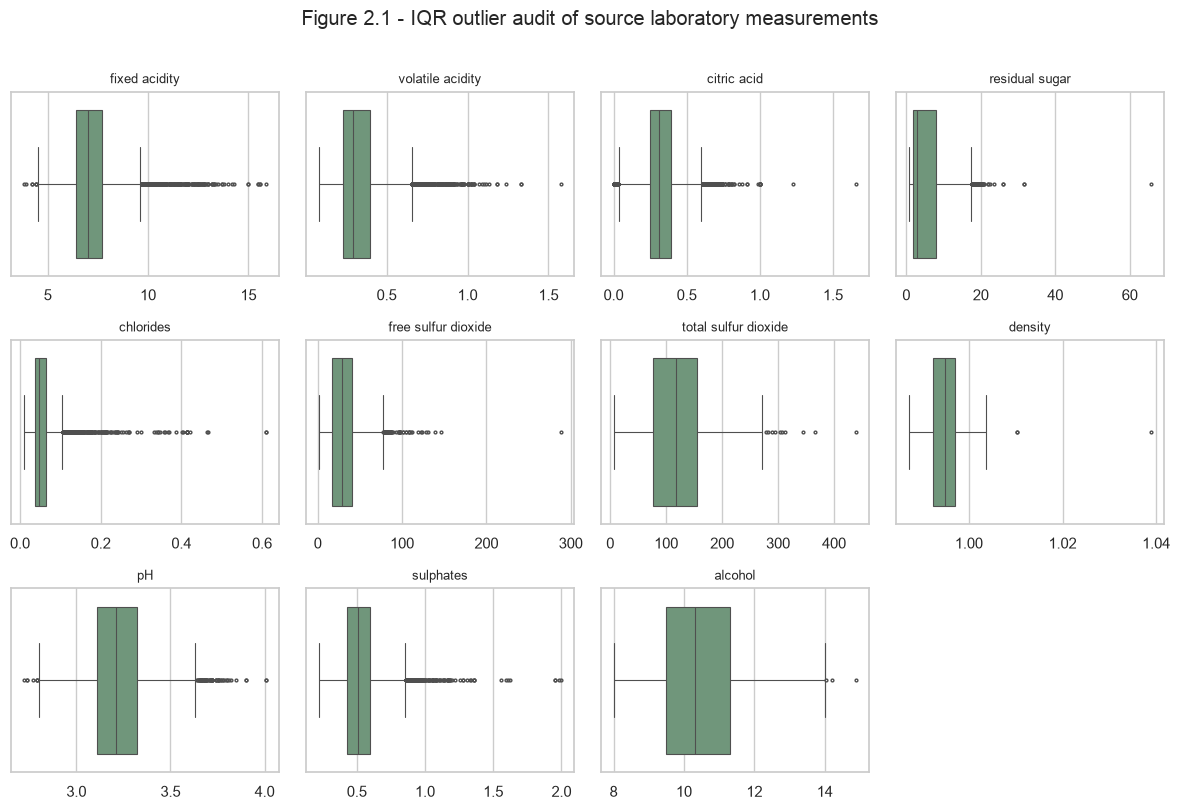

In [6]:
fig, axes = plt.subplots(3, 4, figsize=(12, 8))
for ax, feature in zip(axes.flat, source_features):
    sns.boxplot(x=df[feature], ax=ax, color="#6a9c78", fliersize=2,
                linewidth=0.8)
    ax.set_title(feature, fontsize=9)
    ax.set_xlabel("")
for ax in axes.flat[len(source_features):]:
    ax.axis("off")

fig.suptitle("Figure 2.1 - IQR outlier audit of source laboratory measurements", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "v7_outlier_boxplots.png", dpi=120, bbox_inches="tight")
plt.show()

# Note: IQR flags mark values far from the middle 50% of each feature 
# - they're unusual, not wrong. 
# A sweet dessert wine looks like an outlier but is real wine,
# so I keep them and record the decision."

### 2.4 Target definition, duplicates and class balance

The brief's threshold maps `quality < 6` to low (class 1) and `quality >= 6` to high (class 0). Low is the positive class because it is the event that places a lot on review.

The audit finds 1,177 exact duplicate rows. Because UCI provides no sample or lot identifiers, some of these may be genuinely separate samples with identical recorded values. Removing them is a conservative evaluation choice: it prevents the same feature label record from appearing in both training and test data.

The resulting population has 5,320 rows with a moderate class imbalance: 62.6% high against 37.4% low. Section 3 splits this population into training and held-out test sets.

Raw rows: 6497 | duplicates removed: 1177 | unique rows: 5320

Class counts:
quality_label
high (>=6)    3332
low (<6)      1988

Class proportions:
quality_label
high (>=6)    0.626
low (<6)      0.374


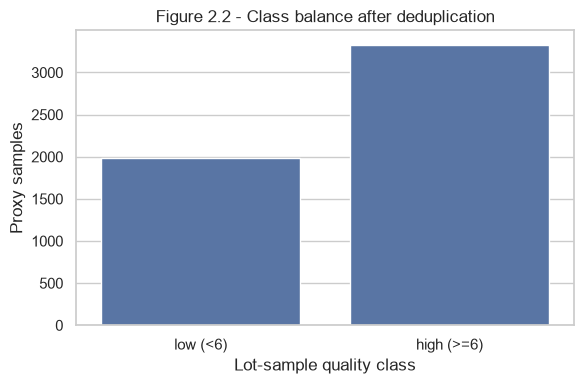

In [7]:
raw_rows = len(df)
duplicate_rows = int(df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

df["quality_label"] = (df["quality"] < 6).astype(int)
label_names = {0: "high (>=6)", 1: "low (<6)"}
df["quality_name"] = df["quality_label"].map(label_names)

counts = df["quality_label"].value_counts().sort_index()
print("Raw rows:", raw_rows,
      "| duplicates removed:", duplicate_rows,
      "| unique rows:", len(df))
print("\nClass counts:")
print(counts.rename(index=label_names).to_string())
print("\nClass proportions:")
print((counts / len(df)).round(3).rename(index=label_names).to_string())

plt.figure(figsize=(6, 4))
sns.countplot(x="quality_name", data=df, order=["low (<6)", "high (>=6)"])
plt.title("Figure 2.2 - Class balance after deduplication")
plt.xlabel("Lot-sample quality class")
plt.ylabel("Proxy samples")
plt.tight_layout()
plt.savefig(FIG_DIR / "v7_class_balance.png", dpi=120)
plt.show()

### 2.5 Relationships with the target

Three views close the Data Understanding stage:
1. The heatmap shows how the laboraty measurements relate to each other, which flags redudant features.
2. The pairplot shows how much the two classes overlap in feature space, which sets expectations for how hard the classification is.
3. Finally, a correlation ranking against quality_label orders the features by association with the target; since low = 1, a positive value means the feature rises with low quality.

Correlation here is a univariate hint, not causation and not model importance: the tree can rank features differently (*in Section 5 we'll see it does*) once interactions are taken into account.

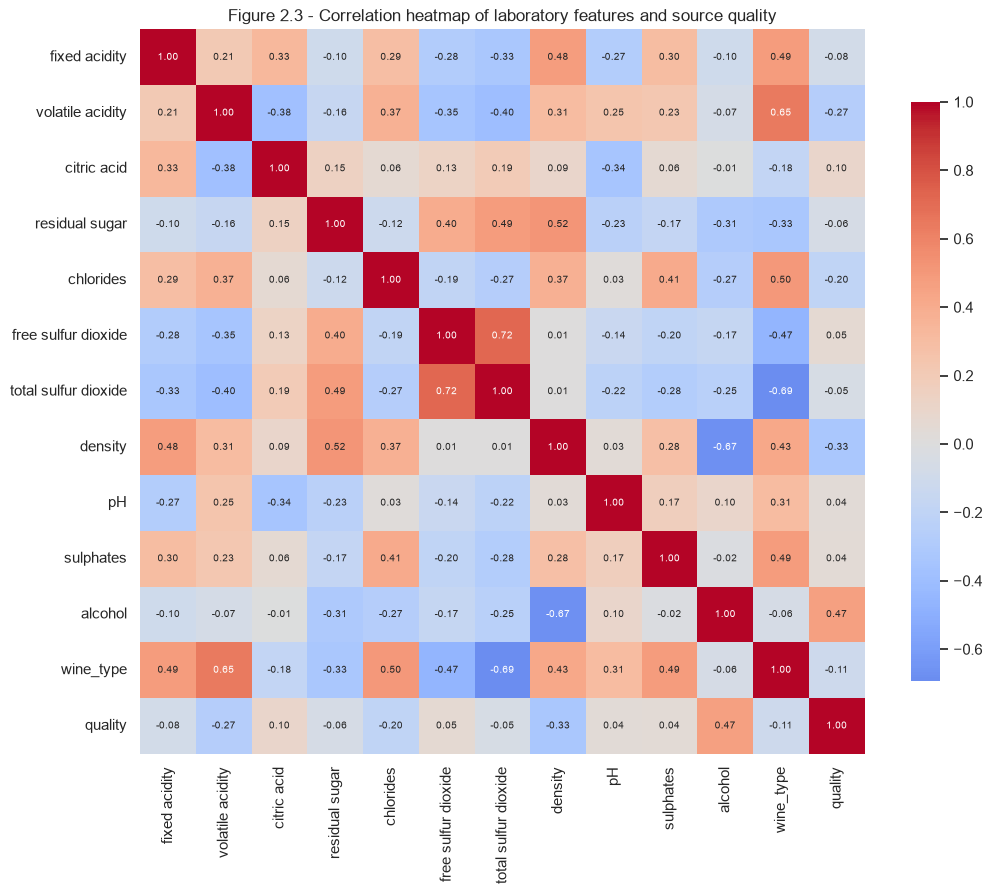

In [8]:
heatmap_columns = source_features + ["wine_type", "quality"]
source_corr = df[heatmap_columns].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(source_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8}, annot_kws={"size": 7})
plt.title("Figure 2.3 - Correlation heatmap of laboratory features and source quality")
plt.tight_layout()
plt.savefig(FIG_DIR / "v7_corr_heatmap.png", dpi=120)
plt.show()

# free and total sulfur dioxide correlate at 0.72 - chemically, total contains free 
# - so in Section 3 I test an engineered bound-SO2 feature to separate them.
# density vs alcohol, -0.67: more alcohol, less dense - alcohol is lighter than water

Table 2.3 - Feature correlations with the low-quality label
Positive values rise with low quality; alcohol has the strongest (negative) association.


,correlation_with_low_quality
alcohol,-0.4145
density,0.2872
volatile acidity,0.2699
chlorides,0.1874
wine_type,0.1177
citric acid,-0.0871
fixed acidity,0.0720
total sulfur dioxide,0.0494
residual sugar,0.0478
free sulfur dioxide,-0.0468


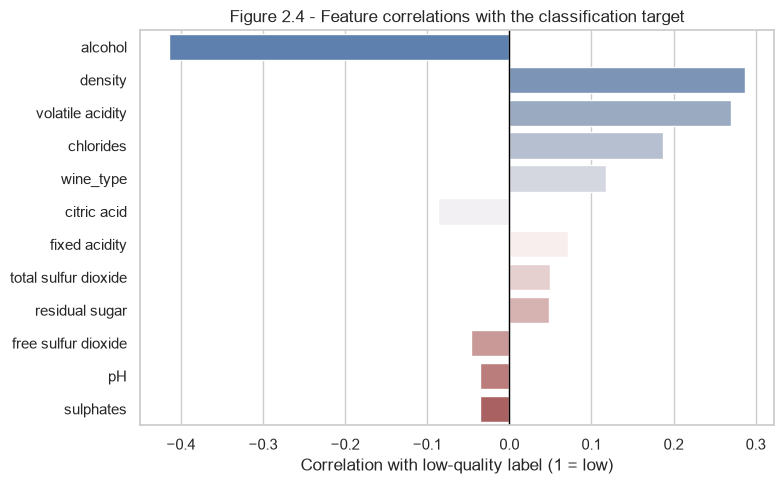

In [9]:
target_corr = (df[source_features + ["wine_type", "quality_label"]]
               .corr()["quality_label"].drop("quality_label"))
target_corr = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index)
target_corr.rename("correlation_with_low_quality").to_csv(
    OUTPUT_DIR / "target_correlations_v7.csv", header=True)

print("Table 2.3 - Feature correlations with the low-quality label")
print("Positive values rise with low quality; alcohol has the strongest (negative) association.")
display(target_corr.rename("correlation_with_low_quality").round(4).to_frame())

plt.figure(figsize=(8, 5))
sns.barplot(x=target_corr.values, y=target_corr.index, hue=target_corr.index,
            palette="vlag", legend=False)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Correlation with low-quality label (1 = low)")
plt.ylabel("")
plt.title("Figure 2.4 - Feature correlations with the classification target")
plt.tight_layout()
plt.savefig(FIG_DIR / "v7_target_correlations.png", dpi=120)
plt.show()

# Alcohol has the strongest association with the target at -0.41
# Since low = 1, a negative correlation means that the highest the alcohol, the lower the probability of low quality

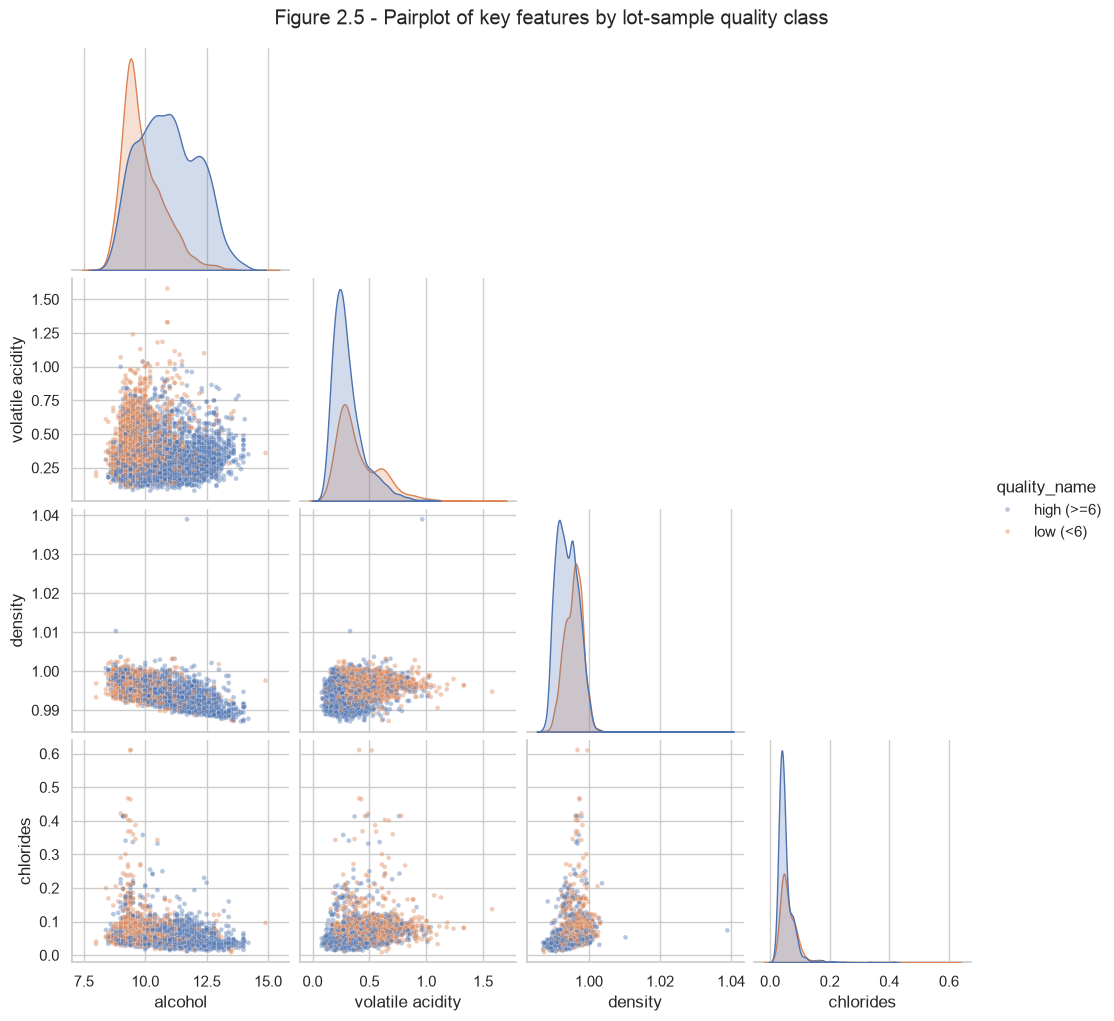

In [10]:
# Top-4 features by absolute correlation with the target (Table 2.3).
pair_cols = ["alcohol", "volatile acidity", "density", "chlorides"]

g = sns.pairplot(df, vars=pair_cols, hue="quality_name",
                 hue_order=["high (>=6)", "low (<6)"], corner=True,
                 plot_kws={"alpha": 0.4, "s": 12}, diag_kind="kde")
g.fig.suptitle("Figure 2.5 - Pairplot of key features by lot-sample quality class", y=1.02)
g.savefig(FIG_DIR / "v7_pairplot.png", dpi=110)
plt.show()

# the classes overlap heavily in every panel 
# no single feature separates low from high, 
# which is why a model that combines them is needed.

Interpretation - Data Understanding summary:

- **Data quality:** schema, numeric types, missing/non-finite values and physical consistency checks all pass. The IQR audit flags 1,473 rows (22.7%), but the values are plausible laboratory measurements, so they are retained.
- **Duplicates:** 1,177 exact duplicate rows are removed before splitting, so no identical record can appear in both training and test data.
- **Feature-to-feature:** free and total SO2 show the strongest positive correlation (0.72), expected because total chemically contains free; this motivates the bound-SO2 engineered feature tested in Section 3. Density and alcohol show the strongest negative correlation (-0.67), expected because alcohol is less dense than water. No other pair is strongly correlated, so the remaining features contribute largely separate information.
- **Relationship with the target:** with low as class 1, alcohol has the strongest association (-0.41): more alcohol, lower chance of low quality. Density (+0.29) and volatile acidity (+0.27) point toward low quality, though part of density's signal reflects its link with alcohol. Correlation is association, not causation.
- **Pairplot:** the four attributes shown are the top-4 by absolute target correlation. The classes overlap heavily in every panel - no single measurement separates low from high, so a model that combines features is required.


| Item | Interpretation |
|---|---|
| Data quality | schema, numeric types, missing/non-finite values and physical consistency checks all pass. The IQR audit flags 1,473 rows (22.7%), but the values are plausible laboratory measurements, so they are retained. |
| Duplicates | 1,177 exact duplicate rows are removed before splitting, so no identical record can appear in both training and test data. |
| Feature-to-feature | free and total SO2 show the strongest positive correlation (0.72), expected because total chemically contains free; this motivates the bound-SO2 engineered feature tested in Section 3. Density and alcohol show the strongest negative correlation (-0.67), expected because alcohol is less dense than water. No other pair is strongly correlated, so the remaining features contribute largely separate information. |
| Relationship with the target | with low as class 1, alcohol has the strongest association (-0.41): more alcohol, lower chance of low quality. Density (+0.29) and volatile acidity (+0.27) point toward low quality, though part of density's signal reflects its link with alcohol. Correlation is association, not causation. |
| Pairplot | the four attributes shown are the top-4 by absolute target correlation. The classes overlap heavily in every panel - no single measurement separates low from high, so a model that combines features is required. |

## 3. Data Preparation

Preparation uses four safeguards:
1. Exact duplicate rows are removed before target engineering and splitting, so no identical record can appear in both training and test data.
2. Source quality and the derived labels are excluded from the predictors, so the model cannot learn the target from a leaked feature. `wine_type` remains available as a predictor.
3. An 80/20 stratified split preserves the class ratio in both partitions and is checked for zero exact overlap.
4. Scaling and SMOTE live inside pipelines, so each cross-validation fold learns its preprocessing from its own training portion only (Chawla et al., 2002; Pedregosa et al., 2011).

Two engineered attributes are then tested on training data only: 
- bound SO2 (`total - free`), motivated by the 0.72 correlation seen in Section 2.5;
- and the free-SO2 ratio (`free / total`), a common quality indicator. 

They are retained only if cross-validated AUC or balanced accuracy improves by at least 0.01 without materially weakening sensitivity or specificity; the verdict is reported in Section 4.1.

In [11]:
LEAK_COLS = ["quality", "quality_label", "quality_name"]
feature_cols = [c for c in df.columns if c not in LEAK_COLS]
X = df[feature_cols]
y = df["quality_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

train_keys = pd.MultiIndex.from_frame(X_train)
test_keys = pd.MultiIndex.from_frame(X_test)
overlap_count = int(test_keys.isin(train_keys).sum())
assert overlap_count == 0, "Exact feature rows leaked across train/test split"
assert set(LEAK_COLS).isdisjoint(X.columns), "Target-derived field entered predictors"

print("=" * 60)
print("Split summary")
print("=" * 60)
print("Train: %d rows | Test: %d rows (%.0f%%/%.0f%%)"
      % (len(X_train), len(X_test), 100 * len(X_train) / len(X),
         100 * len(X_test) / len(X)))
print("Exact train/test feature overlap:", overlap_count)

print("\n" + "-" * 60)
print("Class balance (share of each split)")
print("-" * 60)
balance = pd.DataFrame({
    "train": y_train.value_counts(normalize=True).round(3),
    "test": y_test.value_counts(normalize=True).round(3),
}).rename(index=label_names)
print(balance.to_string())

print("\n" + "-" * 60)
print("Predictors (%d)" % len(feature_cols))
print("-" * 60)
print(", ".join(feature_cols))

Split summary
Train: 4256 rows | Test: 1064 rows (80%/20%)
Exact train/test feature overlap: 0

------------------------------------------------------------
Class balance (share of each split)
------------------------------------------------------------
               train   test
quality_label              
high (>=6)     0.626  0.626
low (<6)       0.374  0.374

------------------------------------------------------------
Predictors (12)
------------------------------------------------------------
fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, alcohol, wine_type


## 4. Modelling

The assessment's brief requires a Decision Tree, so it's the main experiment. Since adding candidates is cheap, six are compared, each answering a different and complementary question:

1. **Majority baseline:** what does "no skill" look like? Every model must beat this floor to be considered useful.
2. **Default tree:** what happens with no constraints? It exposes overfitting and the need for tuning.
3. **Tuned tree:** five-fold `GridSearchCV` searches criterion, depth and minimum leaf size for the best AUC-ROC score, the primary metric set by the brief.
4. **Balanced tree:** keeps the tuned structure and changes only the error cost (`class_weight='balanced'`), so mistakes on the minority class are penalized more heavily, which is expected to improve sensitivity at the cost of specificity.
5. **SMOTE tree:** tests the alternative fix for imbalance with synthetic minority examples, generated inside each training fold only.
6. **SVM kernel search:** a benchmark from a different model family. It ranks the difficulty of the classification problem and provides a sanity check on the tree's performance. It is not the recommended model for this assessment, because it is less interpretable and more computationally expensive than a tree.

Each parameter range behind candidates 3 and 6 has a reason:
- Gini and entropy compare two ways of scoring a split.
- Depths 3 to 8 keep the tree small enough for quality-control staff to understand, but large enough to capture interactions; an unrestricted depth (None) is included as a control, to show what the search rejects.
- Minimum leaf sizes up to 20 test whether broader rules generalize better than rules fitted around small groups of wines.
- For the SVM, `C` sets the penalty for training errors and `gamma` sets how local an RBF boundary can become.
- For scaling runs inside the pipeline, so each fold scales with its own training data only, preventing leakage.

Finally, selection uses training cross-validation only, against the gates declared in Section 1: AUC >= 0.75, low-quality sensitivity >= 0.70, high-quality specificity >= 0.70. The held-out test set plays no part in this choice - it is used only once, in Section 5, to confirm the final model's performance.

In [12]:
# 1 - Majority baseline 
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

# 2 - Default Decision Tree
dt_default = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_default.fit(X_train, y_train)

# 3 - Tune Decision Tree hyperparameters with GridSearchCV
tree_grid = {
    "max_depth": [3, 4, 5, 6, 8, None],
    "min_samples_leaf": [1, 5, 10, 20],
    "criterion": ["gini", "entropy"],
}
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    tree_grid, scoring="roc_auc", cv=5, n_jobs=1)
grid.fit(X_train, y_train)
dt_auc = grid.best_estimator_

# 4 - Balanced Decision Tree (balanced class weights)
tree_structure = {
    "criterion": grid.best_params_["criterion"],
    "max_depth": grid.best_params_["max_depth"],
    "min_samples_leaf": grid.best_params_["min_samples_leaf"],
}
dt_balanced = DecisionTreeClassifier(
    **tree_structure, class_weight="balanced", random_state=RANDOM_STATE)
dt_balanced.fit(X_train, y_train)

# 5- SMOTE tree (synthetic minority samples produced inside each fold)
smote_pipe = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("tree", DecisionTreeClassifier(**tree_structure, random_state=RANDOM_STATE))
])
smote_grid = GridSearchCV(
    smote_pipe,
    {"smote__k_neighbors": [3, 5, 7]},
    scoring="balanced_accuracy", cv=5, n_jobs=1)
smote_grid.fit(X_train, y_train)
dt_smote = smote_grid.best_estimator_

# 6 - SVM with RBF kernel (default hyperparameters)
svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC()),
])
svm_grid = [
    {"svc__kernel": ["linear"], "svc__C": [0.1, 1, 10]},
    {"svc__kernel": ["rbf"], "svc__C": [0.1, 1, 10],
     "svc__gamma": ["scale", "auto"]},
    {"svc__kernel": ["poly"], "svc__C": [0.1, 1, 10],
     "svc__gamma": ["scale", "auto"], "svc__degree": [2, 3]},
    {"svc__kernel": ["sigmoid"], "svc__C": [0.1, 1, 10],
     "svc__gamma": ["scale", "auto"]},
]
svm_search = GridSearchCV(
    svm_pipe, svm_grid, scoring="roc_auc", cv=5, n_jobs=1,
    return_train_score=False)
svm_search.fit(X_train, y_train)
svm_best = svm_search.best_estimator_

models = {
    "Majority baseline": dummy,
    "Decision Tree (default)": dt_default,
    "Decision Tree (AUC-tuned)": dt_auc,
    "Decision Tree (balanced)": dt_balanced,
    "Decision Tree (SMOTE)": dt_smote,
    "SVM (best kernel)": svm_best,
}

print("Tree best params:", grid.best_params_)
print("Tree best CV ROC-AUC: %.3f" % grid.best_score_)
print("SMOTE best params:", smote_grid.best_params_)
print("SVM best params:", svm_search.best_params_)

Tree best params: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 20}
Tree best CV ROC-AUC: 0.791
SMOTE best params: {'smote__k_neighbors': 5}
SVM best params: {'svc__C': 1, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}


### 4.1 Training-only selection and feature ablation

The next 3 cells do one step each, all inside training cross-validation:

1. (4.1.1) Records the tuning results - best tree parameters, SMOTE search and SVM kernel ranking.
2. (4.1.2) Evaluates every candidate against the predeclared gates, using the same five-fold procedure, so the comparison is fair.
3. (4.1.3) Runs the feature ablation announced in Section 3: the two sulfur dioxide features (bound SO2 and free-SO2 ratio) are added as a set, the tree is re-tuned from scratch on the extended features, and the set is retained only if cross-validated AUC or balanced accuracy improves by at least 0.01 without materially weakening sensitivity or specificity.

The held-out test set remains untouched until Section 5.

In [13]:
# 4.1.1 - Record tuning artifacts: best tree params, SMOTE search, SVM kernel ranking
best_params = pd.Series(grid.best_params_, dtype="object").astype(str)
best_params.loc["cv_roc_auc"] = round(grid.best_score_, 4)
best_params.to_csv(OUTPUT_DIR / "tree_best_params_v7.csv", header=["value"])

smote_results = (pd.DataFrame(smote_grid.cv_results_)
                 [["param_smote__k_neighbors", "mean_test_score", "std_test_score", "rank_test_score"]]
                .sort_values("rank_test_score"))
smote_results.to_csv(OUTPUT_DIR / "smote_results_v7.csv", index=False)

svm_cv = pd.DataFrame(svm_search.cv_results_)
svm_kernel_results = (svm_cv.assign(kernel=svm_cv["param_svc__kernel"].astype(str))
                      .groupby("kernel", as_index=False)["mean_test_score"].max()
                      .rename(columns={"mean_test_score": "best_cv_roc_auc"})
                      .sort_values("best_cv_roc_auc", ascending=False))
svm_kernel_results.to_csv(OUTPUT_DIR / "svm_kernel_results_v7.csv", index=False)

print("Table 4.1 - Best decision-tree parameters (5-fold CV, ROC-AUC)")
display(best_params.to_frame("value"))

print("\nTable 4.2 - SVM kernel ranking (best CV ROC-AUC per kernel)")
print("RBF leads; the gap to linear measures how nonlinear the problem is.")
display(svm_kernel_results.round(4))

Table 4.1 - Best decision-tree parameters (5-fold CV, ROC-AUC)


,value
criterion,gini
max_depth,5
min_samples_leaf,20
cv_roc_auc,0.791



Table 4.2 - SVM kernel ranking (best CV ROC-AUC per kernel)
RBF leads; the gap to linear measures how nonlinear the problem is.


,kernel,best_cv_roc_auc
2,rbf,0.8265
0,linear,0.8043
1,poly,0.7950
3,sigmoid,0.7027


In [17]:

# 4.1.2 - Evaluate candidates against the predeclared gates (training CV only)
cv_scoring = {
    "roc_auc": "roc_auc",
    "sensitivity_low": make_scorer(recall_score, pos_label=1),
    "specificity_high": make_scorer(recall_score, pos_label=0),
    "balanced_accuracy": "balanced_accuracy",
    "f1_low": "f1",
}
cv_candidates = {
    "AUC-tuned tree": dt_auc,
    "Balanced tree": dt_balanced,
    "SMOTE tree": dt_smote,
    "RBF SVM": svm_best,
}
cv_rows = []
for model_name, candidate in cv_candidates.items():
    scores = cross_validate(candidate, X_train, y_train, cv=5,
                            scoring=cv_scoring, n_jobs=1)
    row = {"model": model_name}
    for metric in cv_scoring:
        row[metric] = scores["test_" + metric].mean()
        row[metric + "_std"] = scores["test_" + metric].std()
    cv_rows.append(row)

# Create a DataFrame to summarize the cross-validated metrics and check against the predefined gates
cv_comparison = pd.DataFrame(cv_rows).set_index("model")
cv_comparison["passes_auc"] = cv_comparison["roc_auc"] >= 0.75
cv_comparison["passes_sensitivity"] = cv_comparison["sensitivity_low"] >= 0.70
cv_comparison["passes_specificity"] = cv_comparison["specificity_high"] >= 0.70
cv_comparison["passes_all_gates"] = cv_comparison[
    ["passes_auc", "passes_sensitivity", "passes_specificity"]
].all(axis=1)
cv_comparison.to_csv(OUTPUT_DIR / "candidate_cv_metrics_v7.csv")

print("Table 4.3 - Candidates against the predeclared gates (training CV)")
print("Only the Balanced tree passes all three gates.")
cv_display = (cv_comparison[["roc_auc", "sensitivity_low", "specificity_high",
                             "balanced_accuracy", "passes_all_gates"]]
              .rename(columns={"roc_auc": "AUC",
                               "sensitivity_low": "Sensitivity",
                               "specificity_high": "Specificity",
                               "balanced_accuracy": "Balanced acc.",
                               "passes_all_gates": "Pass"}))
display(cv_display.round(3))

Table 4.3 - Candidates against the predeclared gates (training CV)
Only the Balanced tree passes all three gates.


,AUC,Sensitivity,Specificity,Balanced acc.,Pass
model,,,,,
AUC-tuned tree,0.791,0.643,0.787,0.715,False
Balanced tree,0.787,0.731,0.703,0.717,True
SMOTE tree,0.783,0.738,0.696,0.717,False
RBF SVM,0.826,0.631,0.843,0.737,False


In [18]:
# 4.1.3 - Feature ablation announced in Section 3 (bound SO2 + free-SO2 ratio)
# Training-only feature-engineering ablation.
def add_sulfur_features(frame):
    result = frame.copy()
    result["bound_sulfur_dioxide"] = (
        result["total sulfur dioxide"] - result["free sulfur dioxide"]
    )
    result["free_so2_ratio"] = (
        result["free sulfur dioxide"] / result["total sulfur dioxide"]
    )
    return result

X_train_engineered = add_sulfur_features(X_train)
engineered_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    tree_grid, scoring="roc_auc", cv=5, n_jobs=1)
engineered_grid.fit(X_train_engineered, y_train)
engineered_structure = {
    "criterion": engineered_grid.best_params_["criterion"],
    "max_depth": engineered_grid.best_params_["max_depth"],
    "min_samples_leaf": engineered_grid.best_params_["min_samples_leaf"],
}
engineered_balanced = DecisionTreeClassifier(
    **engineered_structure, class_weight="balanced", random_state=RANDOM_STATE)
engineered_scores = cross_validate(
    engineered_balanced, X_train_engineered, y_train, cv=5,
    scoring=cv_scoring, n_jobs=1)

base_balanced = cv_comparison.loc["Balanced tree"]
ablation = pd.DataFrame([
    {
        "feature_set": "Base 12 features",
        "tuned_cv_auc": grid.best_score_,
        "balanced_tree_cv_auc": base_balanced["roc_auc"],
        "sensitivity_low": base_balanced["sensitivity_low"],
        "specificity_high": base_balanced["specificity_high"],
        "balanced_accuracy": base_balanced["balanced_accuracy"],
        "retained": True,
    },
    {
        "feature_set": "Base + bound SO2 + free SO2 ratio",
        "tuned_cv_auc": engineered_grid.best_score_,
        "balanced_tree_cv_auc": engineered_scores["test_roc_auc"].mean(),
        "sensitivity_low": engineered_scores["test_sensitivity_low"].mean(),
        "specificity_high": engineered_scores["test_specificity_high"].mean(),
        "balanced_accuracy": engineered_scores["test_balanced_accuracy"].mean(),
        "retained": False,
    },
])
ablation.to_csv(OUTPUT_DIR / "feature_ablation_v7.csv", index=False)

print("Table 4.4 - Feature ablation verdict (training CV)")
print("Gain 0.0075 in balanced accuracy is below the 0.01 rule; the sulfur set is rejected.")
ablation_display = (ablation[["feature_set", "tuned_cv_auc",
                              "balanced_accuracy", "retained"]]
                    .rename(columns={"feature_set": "Feature set",
                                     "tuned_cv_auc": "Tuned AUC",
                                     "balanced_accuracy": "Balanced acc.",
                                     "retained": "Retain"})
                    .set_index("Feature set"))
display(ablation_display.round(3))

Table 4.4 - Feature ablation verdict (training CV)
Gain 0.0075 in balanced accuracy is below the 0.01 rule; the sulfur set is rejected.


,Tuned AUC,Balanced acc.,Retain
Feature set,,,
Base 12 features,0.791,0.717,True
Base + bound SO2 + free SO2 ratio,0.789,0.724,False
